# Linear Algebra

David Evans  
2026-02-06

# Introduction

## Motivation

### Systems of Linear Equations

-   One of the most commonly used branches of mathematics in economics
-   Many applied problems require solutions to systems of linear
    equations

$$
\begin{split}\begin{array}{c}
    y_1 = a x_1 + b x_2 \\
    y_2 = c x_1 + d x_2
\end{array}\end{split}
$$

. . .

-   Or, more generally

$$
\begin{split}\begin{array}{c}
    y_1 = a_{11} x_1 + a_{12} x_2 + \cdots + a_{1k} x_k \\
    \vdots  \\
    y_n = a_{n1} x_1 + a_{n2} x_2 + \cdots + a_{nk} x_k
\end{array}\end{split}
$$

-   Objective: solve for $x_1,\ldots, x_k$ given $a_{ij}$ and
    $y_1,\ldots,y_n$

### Questions We’ll Answer

-   Does a solution actually exist?
-   Are there in fact many solutions, and if so how should we interpret
    them?
-   If no solution exists, is there a “best” approximate solution?
-   If a solution exists, how should we compute it?

. . .

> **This Lecture**
>
> We will show how to use Julia to solve these problems numerically.

# Vectors

## Definition

### Vectors

-   A vector of length $n$ is just a sequence of $n$ numbers which we
    write as

$$
 x = \left(\begin{matrix} x_1\\\vdots\\ x_n\end{matrix}\right)
$$

-   The set of all $n$-vectors is denoted by $\mathbb{R}^n$
-   For example, $\mathbb{R}^2$ is the plane, and a vector in
    $\mathbb{R}^2$ is just a point on the plane

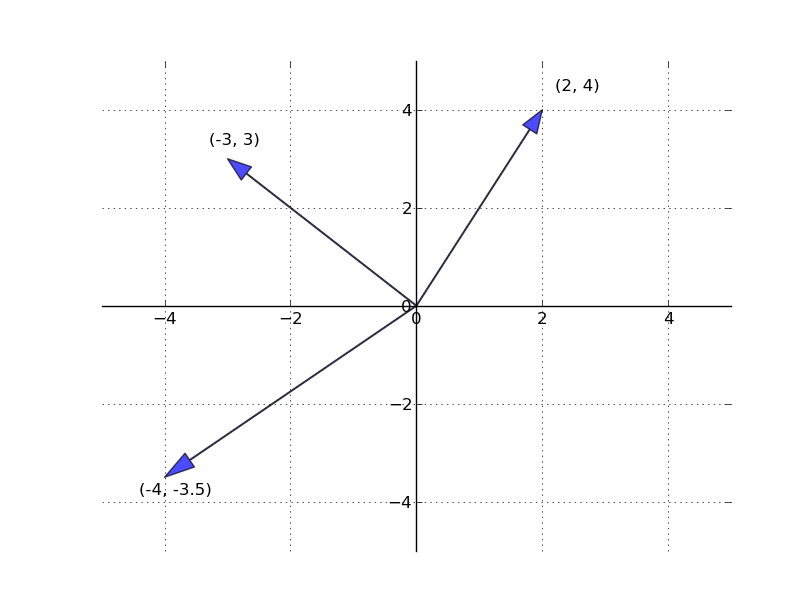

### Vectors in Julia

-   Julia is built with vectors and matrices as fundamental building
    blocks

In [1]:
using LinearAlgebra

In [1]:
x = [1., 2.]

2-element Vector{Float64}:
 1.0
 2.0

. . .

-   There are multiple ways of constructing arrays:

In [1]:
x = zeros(3)           # R^3 filled with zeros
println("x = $x")
y = ones(4)            # R^4 filled with ones
println("y = $y")
z = collect(LinRange(0, 1, 6))  # R^6 evenly spaced between 0,1
println("z = $z")

x = [0.0, 0.0, 0.0]
y = [1.0, 1.0, 1.0, 1.0]
z = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

### Editing Vectors

-   Once an array is created we can edit elements using `[]`

In [1]:
x[1] = 1
x

3-element Vector{Float64}:
 1.0
 0.0
 0.0

. . .

-   Using `:` you can access multiple elements at once

In [1]:
println(x[2:3])

[0.0, 0.0]

### Assigning to Slices

-   Assigning to slices requires `.=` (dot means “do for each element”)

In [1]:
x[2:3] = 3, 4  # produces error

. . .

In [1]:
x[2:3] .= 3, 4  # assigns element-wise
x

3-element Vector{Float64}:
 1.0
 3.0
 4.0

## Vector Operations

### Vector Addition

-   When we add two vectors we add them element by element

$$
\begin{split}x + y
=
\left[
\begin{array}{c}
    x_1 \\
    x_2 \\
    \vdots \\
    x_n
\end{array}
\right]
+
\left[
\begin{array}{c}
     y_1 \\
     y_2 \\
    \vdots \\
     y_n
\end{array}
\right]
:=
\left[
\begin{array}{c}
    x_1 + y_1 \\
    x_2 + y_2 \\
    \vdots \\
    x_n + y_n
\end{array}
\right]\end{split}
$$

In [1]:
x = ones(3)
y = [2, 4, 6]
x + y

3-element Vector{Float64}:
 3.0
 5.0
 7.0

### Scalar Multiplication

-   Scalar multiplication takes a scalar $\gamma$ and a vector $x$ and
    produces

$$
\begin{split}\gamma x
:=
\left[
\begin{array}{c}
    \gamma x_1 \\
    \gamma x_2 \\
    \vdots \\
    \gamma x_n
\end{array}
\right]\end{split}
$$

In [1]:
4*x

3-element Vector{Float64}:
 4.0
 4.0
 4.0

. . .

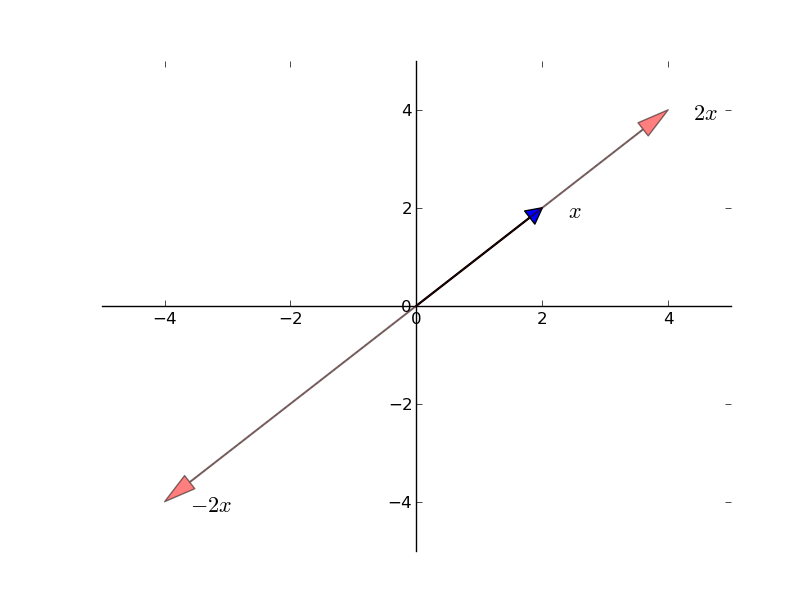

### Element-wise Multiplication

-   Can also multiply $x$ and $y$ element-wise with `.*` notation

In [1]:
println(x, y)  # recall what x and y are
xy = x .* y

[1.0, 1.0, 1.0][2, 4, 6]

3-element Vector{Float64}:
 2.0
 4.0
 6.0

. . .

> **The Dot Operator**
>
> In Julia, prefixing an operator with `.` applies it element-wise. This
> works with any function or operator!

### Inner Products and Norms

-   The inner product of two vectors $x, y \in \mathbb{R}^n$ is defined
    as

$$
x' y := \sum_{i=1}^n x_i y_i
$$

-   Two vectors are **orthogonal** if their inner product is zero
-   The **norm** of a vector $x$ represents its “length”:

$$
\| x \| := \sqrt{x' x} := \left( \sum_{i=1}^n x_i^2 \right)^{1/2}
$$

### Inner Products in Julia

In [1]:
# Two ways of doing inner product
println(sum(x .* y))   # sums over x.*y
println(dot(x, y))     # directly computes dot product

12.0
12.0

In [1]:
# Two ways of computing the norm
println(sqrt(dot(x, x)))
println(norm(x))

1.7320508075688772
1.7320508075688772

. . .

In [1]:
# Example of orthogonal vectors
z = [-1., 2., -1]
println(dot(x, z))

0.0

# Spanning and Linear Independence

## Linear Combinations

### Spanning

-   Given vectors $A = \{a_1,\ldots,a_k\}\subset \mathbb{R}^n$, what new
    vectors can we create using linear operations?
-   $y \in \mathbb{R}^n$ is a **linear combination** of $A$ if

$$
    y = \beta_1 a_1 + \beta_2 a_2 + \ldots + \beta_k a_k \text{  for some scalars $\beta_1,\ldots,\beta_k$}
$$

-   The set of linear combinations of $A$ is called the **span** of $A$

. . .

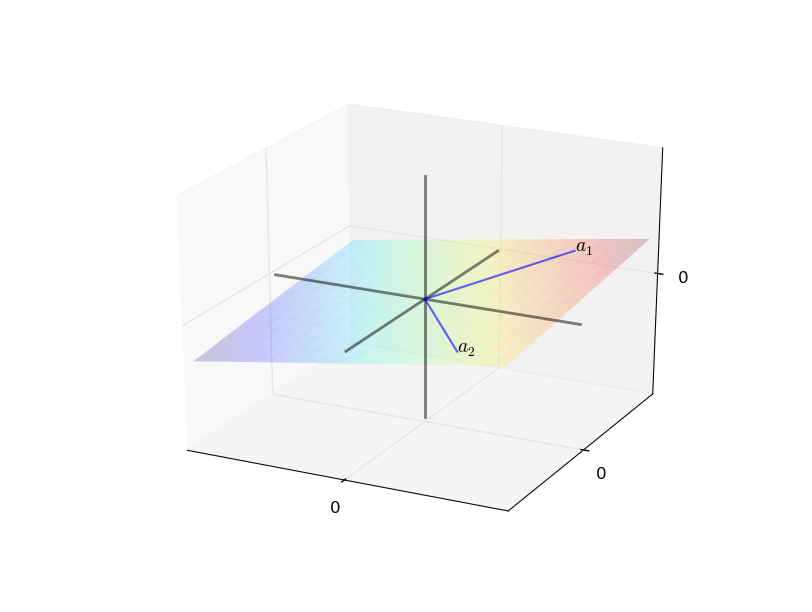

### Spanning Examples

-   If $A$ contains only 1 vector $a_1 \in \mathbb{R}^n$, its span is
    the line through $a_1$ and the origin

. . .

-   The canonical basis vectors $e_1, e_2, \ldots, e_n$ in
    $\mathbb{R}^n$:

$$
    e_1 = \left[\begin{matrix}1\\0\\\vdots\\0\end{matrix}\right],\quad
    e_2 = \left[\begin{matrix}0\\1\\\vdots\\0\end{matrix}\right],\quad\ldots,\quad
    e_n = \left[\begin{matrix}0\\0\\\vdots\\1\end{matrix}\right]
$$

### The Canonical Basis Spans $\mathbb{R}^n$

-   The span of $\{e_1, e_2, \ldots, e_n\}$ is all of $\mathbb{R}^n$
    because for any $x \in \mathbb{R}^n$:

$$
    x = x_1 e_1 + x_2 e_2 + \ldots + x_n e_n
$$

### Spanning: A Counterexample

-   Let $A_0 = \{e_1, e_2, e_1 + e_2\} \subset \mathbb{R}^3$
    -   If $y = (y_1, y_2, y_3)$ is a linear combination of these
        vectors then $y_3 = 0$
    -   $A_0$ fails to span all of $\mathbb{R}^3$

. . .

> **Key Insight**
>
> Adding more vectors doesn’t always increase the span — the new vector
> must point in a “genuinely new direction.”

## Linear Independence

### Linear Independence

-   $A = \{a_1, \ldots, a_k\} \subset \mathbb{R}^n$ is **linearly
    dependent** if a strict subset has the same span
-   $A$ is **linearly independent** if no such subset exists

. . .

-   Since $\mathbb{R}^n$ can be spanned by $n$ vectors, any subset with
    $m > n$ elements must be linearly dependent

. . .

-   Equivalent definitions:
    1.  No vector in $A$ can be formed as a linear combination of the
        others
    2.  If $\beta_1 a_1 + \ldots + \beta_k a_k = 0$ then
        $\beta_1 = \cdots = \beta_k = 0$

### Unique Representations

-   Linearly independent vectors give **unique** representations in
    their span
-   If $A = \{a_1, \ldots, a_k\}$ is linearly independent and

$$
y = \beta_1 a_1 + \ldots + \beta_k a_k = \gamma_1 a_1 + \ldots + \gamma_k a_k
$$

. . .

-   Subtracting:

$$
(\beta_1 - \gamma_1) a_1 + \cdots + (\beta_k - \gamma_k) a_k = 0
$$

-   By linear independence: $\gamma_i = \beta_i$ for all $i$

# Matrices

## Definition

### Matrices

-   An $n \times k$ matrix is a rectangular array with $n$ rows and $k$
    columns

$$
\begin{split}A =
\left[
\begin{array}{cccc}
    a_{11} & a_{12} & \cdots & a_{1k} \\
    a_{21} & a_{22} & \cdots & a_{2k} \\
    \vdots & \vdots & \vdots \\
    a_{n1} & a_{n2} & \cdots & a_{nk}
\end{array}
\right]\end{split}
$$

. . .

-   Can also view $A$ as a list of $k$ column vectors in $\mathbb{R}^n$:

$$
    A = \left[\begin{matrix}a_1 & a_2 & \cdots & a_k\end{matrix}\right]
    \quad\text{where}\quad
    a_i = \left[\begin{matrix} a_{1i}\\ a_{2i} \\\vdots \\  a_{ni}\end{matrix}\right]
$$

### Matrix Properties

-   **Row vector**: $n = 1$; **Column vector**: $k = 1$; **Square**:
    $n = k$
-   The **transpose** $A'$ (or $A^T$) is formed by swapping rows and
    columns ($a_{ij} \to a_{ji}$)

$$
\begin{split}A =
\left[
\begin{array}{ccc}
    a_{11} & a_{12} & \cdots & a_{1k} \\
    \vdots & \vdots &  \vdots \\
    a_{n1} & a_{n2} & \cdots & a_{nk}
\end{array}
\right]
\quad
A' =
\left[
\begin{array}{ccc}
    a_{11} & a_{21} & \cdots & a_{n1} \\
    \vdots & \vdots &  \vdots \\
    a_{1k} & a_{2k} & \cdots & a_{nk}
\end{array}
\right]\end{split}
$$

-   If $A$ is $n \times k$ then $A'$ is $k \times n$

### Transpose in Julia

In [1]:
A = [1 2 3;
     4 5 6]

2×3 Matrix{Int64}:
 1  2  3
 4  5  6

In [1]:
A'  # transpose is natural in Julia

3×2 adjoint(::Matrix{Int64}) with eltype Int64:
 1  4
 2  5
 3  6

## Special Matrices

### Symmetric Matrices

-   For square matrices, if $A = A'$ then $A$ is called **symmetric**

In [1]:
A = [1 2; 2 1]

2×2 Matrix{Int64}:
 1  2
 2  1

In [1]:
A'  # same as A!

2×2 adjoint(::Matrix{Int64}) with eltype Int64:
 1  2
 2  1

. . .

-   The **principal diagonal** elements are $a_{ii}$ for
    $i = 1, \ldots, n$

In [1]:
A = [1 2;
     3 4]

2×2 Matrix{Int64}:
 1  2
 3  4

In [1]:
diag(A)  # grabs diagonal of A

2-element Vector{Int64}:
 1
 4

### Diagonal Matrices

-   $A$ is **diagonal** if the only non-zero entries are on the
    principal diagonal

In [1]:
diagm(0 => [1, 2, 3])  # puts 1,2,3 on the diagonal

3×3 Matrix{Int64}:
 1  0  0
 0  2  0
 0  0  3

In [1]:
diagm(1 => [1, 2, 3])  # shift up by 1

4×4 Matrix{Int64}:
 0  1  0  0
 0  0  2  0
 0  0  0  3
 0  0  0  0

### The Identity Matrix

-   The **identity matrix** $I$ has ones on the diagonal:

In [1]:
diagm(0 => ones(3))

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

$$
    I = \left[\begin{matrix}e_1 & e_2 & \cdots & e_n\end{matrix}\right]
$$

## Matrix Operations

### Addition and Scalar Multiplication

-   Both carry over directly from vector definitions

$$
\gamma A := \left[
\begin{array}{ccc}
    \gamma a_{11} & \cdots & \gamma a_{1k} \\
    \vdots & \vdots &  \vdots \\
    \gamma a_{n1} & \cdots & \gamma a_{nk}
\end{array}
\right]
$$

-   For $A + B$ both matrices must be $n \times k$

In [1]:
A = [1 2; 3 4]
B = diagm(0 => ones(2))
2*A

2×2 Matrix{Int64}:
 2  4
 6  8

In [1]:
A + B

2×2 Matrix{Float64}:
 2.0  2.0
 3.0  5.0

### Matrix Multiplication

-   The $i, j$-th element of $AB$ is the inner product of row $i$ of $A$
    and column $j$ of $B$

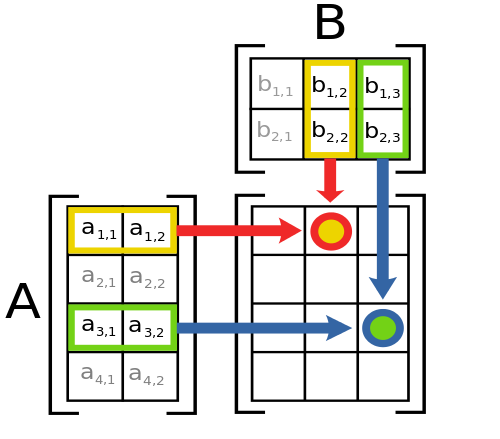

-   $A$ must be $n \times k$ and $B$ must be $k \times m$
-   In general $AB \neq BA$

### Matrix-Vector Multiplication

-   Multiplying $n \times k$ matrix $A$ with $k \times 1$ vector $x$
    gives $n \times 1$ vector:

$$
Ax =
\left[
\begin{array}{c}
    a_{11} x_1 + \cdots + a_{1k} x_k \\
    \vdots \\
    a_{n1} x_1 + \cdots + a_{nk} x_k
\end{array}
\right]
$$

### Matrix-Vector Multiplication as Linear Combination

-   If $a_1, \ldots, a_k$ are the columns of $A$:

$$
    Ax = x_1 a_1 + x_2 a_2 + \ldots + x_k a_k
$$

-   Thus $Ax$ is in the **span** of $A$
-   Identity matrices have the property: $IA = A = AI$

### Matrix Multiplication in Julia

In [1]:
A = [1 2; 3 4]

2×2 Matrix{Int64}:
 1  2
 3  4

In [1]:
I2 = diagm(0 => ones(2))

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

In [1]:
A * I2   # should just give A

2×2 Matrix{Float64}:
 1.0  2.0
 3.0  4.0

### Element-wise vs. Matrix Multiplication

-   Element-wise multiplication via `.*`

In [1]:
A .* I2

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  4.0

. . .

-   Julia has a built-in variable `I` for the identity matrix

In [1]:
A * I

2×2 Matrix{Int64}:
 1  2
 3  4

## Broadcasting

### Broadcasting

-   Broadcasting replicates operations across dimensions using `.`
    notation
-   Allows you to, for instance, add a vector to each column of a matrix

In [1]:
A = diagm(0 => ones(2))

2×2 Matrix{Float64}:
 1.0  0.0
 0.0  1.0

In [1]:
b = [1, 2]

2-element Vector{Int64}:
 1
 2

In [1]:
A .+ b   # adds b to each column of A

2×2 Matrix{Float64}:
 2.0  1.0
 2.0  3.0

### Broadcasting Rules

-   Julia compares array shapes element-wise, starting from trailing
    dimensions
-   Two dimensions are compatible when:
    1.  They are equal, or
    2.  One of them has length 1

. . .

Can these arrays be broadcast together?

`A      (4d array):  8 x 1 x 6 x 1` `B      (3d array):      7 x 1 x 5`
`Result (4d array):  8 x 7 x 6 x 5`

. . .

What about these?

`A      (2d array):      2 x 1` `B      (3d array):  8 x 4 x 3`

No — the second dimensions do not match.

# Solving Systems of Equations

## Formulation

### Systems as Matrix Equations

-   Our original system can be written as $y = Ax$

$$
\begin{split}\begin{array}{c}
    y_1 = a_{11} x_1 + a_{12} x_2 + \cdots + a_{1k} x_k \\
    \vdots  \\
    y_n = a_{n1} x_1 + a_{n2} x_2 + \cdots + a_{nk} x_k
\end{array}\end{split}
$$

. . .

-   Since $Ax = x_1 a_1 + \ldots + x_k a_k$, the solution requires $y$
    to be in the span of $A$
-   If the columns of $A$ are linearly independent and span
    $\mathbb{R}^n$, a **unique** solution exists
-   We say $A$ has **full column rank**

## Regular Case

### The Regular Case

-   When $A$ is $n \times n$ with linearly independent columns:
    -   $y = Ax$ has a solution for every $y$, and this solution is
        unique
-   Define $g(y)$ as the solution: $y = Ag(y)$

. . .

-   $g(y)$ is a linear function:

$$
g(\alpha w + \beta z) = \alpha g(w) + \beta g(z)
$$

-   Any linear function can be represented by a matrix, so there exists
    $A^{-1}$ such that $g(y) = A^{-1}y$

### The Inverse Matrix

-   If $A$ is $n \times n$ with full column rank, there exists $A^{-1}$
    such that

$$
    I = A^{-1}A = A A^{-1}
$$

-   Pre-multiplying $y = Ax$ by $A^{-1}$:

$$
    A^{-1} y = A^{-1} A x = x
$$

. . .

-   **Determinant test**: if $\det(A) \neq 0$ then $A$ is invertible
-   If $\det(A) = 0$ then the columns are linearly dependent and no
    inverse exists

> **Key Result**
>
> $x = A^{-1}y$ is the solution to $y = Ax$ when $A$ is square and
> invertible.

### Solving in Julia: The Inverse

In [1]:
A = [1 2; 3 4]
y = ones(2)
det(A)   # check det(A) ≠ 0

-2.0

In [1]:
A_inv = inv(A)

2×2 Matrix{Float64}:
 -2.0   1.0
  1.5  -0.5

In [1]:
x = A_inv * y

2-element Vector{Float64}:
 -0.9999999999999998
  0.9999999999999999

In [1]:
A * x   # verify: should give y

2-element Vector{Float64}:
 1.0
 1.0000000000000004

### Solving in Julia: The Backslash Operator

-   Can also use `A\y` (backslash) to solve directly

In [1]:
x = A \ y

2-element Vector{Float64}:
 -1.0
  1.0

> **Best Practice**
>
> Prefer `A\y` over `inv(A)*y` — it is more numerically stable and
> efficient.

## Over-determined Systems

### Over-determined Systems

-   When $A$ is $n \times k$ with $n > k$ (more equations than unknowns)
-   This case arises frequently in **least-squares regression**
-   The span of $A$ is unlikely to contain an arbitrary
    $y \in \mathbb{R}^n$

. . .

-   Instead, find $x$ that minimizes $\| y - Ax \|$
-   The solution is $\hat{x} = (A'A)^{-1}A'y$ when $A$ has full column
    rank
-   Julia provides the pseudo-inverse via `pinv`

### Least-Squares Example

Fit a line $y = mx + c$ through noisy data:

In [1]:
x = [0, 1, 2, 3]
y = [-1, 0.2, 0.9, 2.1]

4-element Vector{Float64}:
 -1.0
  0.2
  0.9
  2.1

. . .

Rewrite as $y = Ap$ where $A = [x \;\; 1]$ and $p = [m \;\; c]$:

In [1]:
A = [x ones(length(x))]

4×2 Matrix{Float64}:
 0.0  1.0
 1.0  1.0
 2.0  1.0
 3.0  1.0

### Least-Squares Solution

In [1]:
m, c = pinv(A) * y
print(m, c)

1.0000000000000002-0.9499999999999998

. . .

Matches our formula $(A'A)^{-1}A'y$:

In [1]:
(A' * A) \ A' * y

2-element Vector{Float64}:
  0.9999999999999998
 -0.9499999999999996

### Plotting the Fit

In [1]:
using Plots


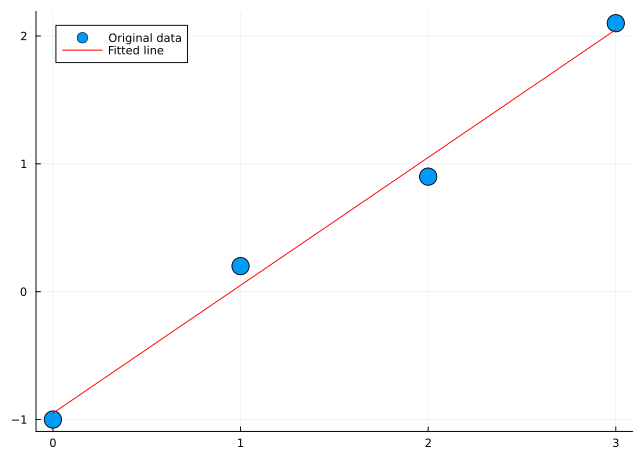

In [1]:
scatter(x, y, label="Original data", markersize=10)
plot!(x, m*x .+ c, color=:red, label="Fitted line")

## Under-determined Systems

### Under-determined Systems

-   If $A$ is $n \times k$ with $n < k$: fewer equations than unknowns
-   Expect either no solutions or **infinitely many** solutions

. . .

-   The **kernel** $\ker(A)$ is the set of all $x$ such that $Ax = 0$
-   If $x$ solves $y = Ax$ and $\hat{x} \in \ker(A)$, then $x + \hat{x}$
    is also a solution:

$$
A(x + \hat{x}) = Ax + A\hat{x} = Ax + 0 = y
$$

. . .

> **Caution**
>
> Under-determined systems have infinitely many solutions. Methods like
> `pinv` return the solution with smallest norm $\|x\|$.

# Eigenvalues and Eigenvectors

## Definition

### Eigenvectors and Eigenvalues

-   For an $n \times n$ matrix $A$, we want to find scalar $\lambda$ and
    vector $v \in \mathbb{R}^n$ such that

$$
 Av = \lambda v
$$

-   The operation $Av$ returns a **scalar multiple** of $v$

. . .

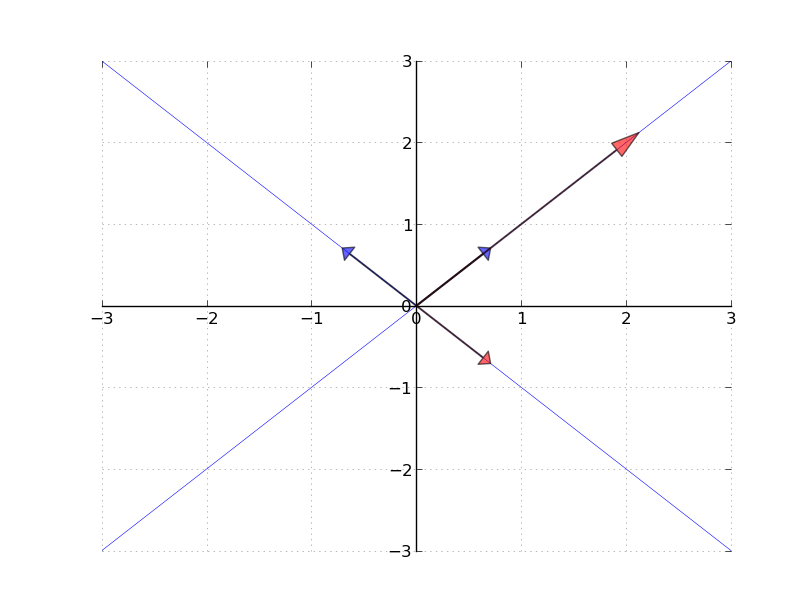

### Finding Eigenvalues

-   Rearranging: $0 = Av - \lambda v = (A - \lambda I)v$
-   An eigenvalue exists when the columns of $A - \lambda I$ are
    linearly dependent

. . .

-   We search for $\lambda$ such that $\det(A - \lambda I) = 0$
-   $\det(A - \lambda I)$ is a polynomial of degree $n$; its roots are
    the eigenvalues

### Eigenvalue Properties

Nice facts about the eigenvalues of a square matrix $A$:

1.  The **determinant** of $A$ equals the product of its eigenvalues
2.  The **trace** of $A$ (sum of diagonal elements) equals the sum of
    its eigenvalues
3.  If $A$ is **symmetric**, all eigenvalues are real
4.  If $A$ is invertible with eigenvalues
    $\lambda_1, \ldots, \lambda_n$, then $A^{-1}$ has eigenvalues
    $1/\lambda_1, \ldots, 1/\lambda_n$

### Eigenvalues in Julia

In [1]:
A = [1 2; 2 1];
evals, evecs = eigen(A)

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
2-element Vector{Float64}:
 -1.0
  3.0
vectors:
2×2 Matrix{Float64}:
 -0.707107  0.707107
  0.707107  0.707107

In [1]:
evals   # eigenvalues

2-element Vector{Float64}:
 -1.0
  3.0

In [1]:
evecs   # eigenvectors (columns)

2×2 Matrix{Float64}:
 -0.707107  0.707107
  0.707107  0.707107

. . .

> **Reading the Output**
>
> The columns of `evecs` are the eigenvectors corresponding to the
> eigenvalues in `evals`.

# Summary

### Key Takeaways

**Concepts**

-   Vectors and vector spaces
-   Spanning and linear independence
-   Matrix operations and multiplication
-   Inverse matrices and determinants
-   Eigenvalues and eigenvectors

**Julia Tools**

-   `LinearAlgebra` package
-   `dot`, `norm`, `det`
-   `inv(A)`, `A\y`
-   `pinv(A)` for least-squares
-   `eigen(A)` for eigenvalues
-   `.*`, `.+` for broadcasting

. . .

> **Remember**
>
> Use `A\y` instead of `inv(A)*y` for solving systems — it’s faster and
> more stable!